In [79]:
import tiktoken
from langchain.text_splitter import MarkdownHeaderTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

from agent_k.config.logger import logger


def count_tokens(text):
    try:
        encoding = tiktoken.get_encoding("cl100k_base")
        return len(encoding.encode(text))
    except Exception as e:
        logger.warning(f"Error counting tokens: {e}")
        logger.warning("Falling back to rough approximation (4 tokens per character)")
        return len(text) // 4


headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

with open(
    "data/processed/43-101/02a2b93ee61f2863bcb417b27855cb63d63a3c53b73622174f7c5688b0d4dc159c.md",
    "r",
) as file:
    markdown_document = file.read()

markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
markdown_document_tokens = count_tokens(markdown_document)
logger.info(f"Number of tokens: {markdown_document_tokens}")

doc_splits = markdown_splitter.split_text(markdown_document)
doc_splits_len = len(doc_splits)
logger.info(f"Number of splits: {doc_splits_len}")

avg_tokens = markdown_document_tokens / doc_splits_len
logger.info(f"Average tokens per split: {avg_tokens:.0f}")

2025-03-16 20:33:41.403 | INFO     | __main__:<module>:27 - Number of tokens: 77834
2025-03-16 20:33:41.421 | INFO     | __main__:<module>:31 - Number of splits: 115
2025-03-16 20:33:41.421 | INFO     | __main__:<module>:34 - Average tokens per split: 677


In [80]:
doc_splits

[Document(metadata={'Header 2': 'MINERAL RESOURCES AND RESERVES OF THE'}, page_content='PANASQUEIRA MINE, PORTUGAL  \nPrepared for  \nAlmonty Industries by  \nQualified Person:  \nAdam Wheeler, B.Sc, M.Sc, C. Eng, FIMMM  \n31 st December 2016  \nMining Consultant  \nCambrose Farm, Redruth  \nCornwall, TR16 4HT  \nEngland.  \nE-mail:  \nadamwheeler@btinternet.com'),
 Document(metadata={'Header 2': 'TABLE OF CONTENTS'}, page_content='| 1 SUMMARY..................................................................................................................... 8                                                                                                                       | 1 SUMMARY..................................................................................................................... 8                                                                                                                       | 1 SUMMARY.......................................................

In [81]:
# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=OpenAIEmbeddings(model="text-embedding-3-small"),
)
retriever = vectorstore.as_retriever()

In [82]:
### Retrieval Grader


from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

from agent_k.config.schemas import TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION


# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    reasoning: str = Field(
        description="Reasoning why the document is relevant to the question or not"
    )
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

QUESTION_TEMPLATE = """**Question:** What's the {field} of the mineral site in the attached 43-101 report?
**Data type of {field}:** {dtype}
**Default value of {field} if not found:** {default}
**Description of {field}:** {description}"""
question = QUESTION_TEMPLATE.format(
    field="total_mineral_resource_tonnage",
    dtype="float",
    default=0,
    description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
)
logger.info(question)

docs = retriever.invoke(question)
docs

2025-03-16 20:33:44.490 | INFO     | __main__:<module>:45 - **Question:** What's the total_mineral_resource_tonnage of the mineral site in the attached 43-101 report?
**Data type of total_mineral_resource_tonnage:** float
**Default value of total_mineral_resource_tonnage if not found:** 0
**Description of total_mineral_resource_tonnage:** The total mineral resource tonnage of the mineral site converted to million tonnes. The total mineral resource tonnage is calculated by summing up the tonnage of all individual inferred, indicated, and measured mineral resources across all the mineral zones.

Example: if we have 1000 tonnes of inferred mineral resources, 2000 tonnes of indicated mineral resources, and 3000 tonnes of measured mineral resources, the total mineral resource tonnage is 1000 + 2000 + 3000 = 6000 tonnes or 6000/1000000 = 0.006 million tonnes.


[Document(metadata={'Header 2': '14.4 Resources Overview'}, page_content='An overall summary of resources from both the mine and tailings areas are summarised in Table 14-31.  \nTable 14-31. Overall Resource Summary  \n| CATEGORY             | Tonnes Kt   |   WO3 % | WO3 MTU x1000   |\n|----------------------|-------------|---------|-----------------|\n| Measured             | 1,951       |    0.2  | 393             |\n| Indicated            | 8,076       |    0.24 | 1,920           |\n| Measured + Indicated | 10,027      |    0.23 | 2,313           |  \n| CATEGORY   | CATEGORY   | Tonnes Kt   |   WO3 % | WO3 MTU x1000   | Cu %   | Sn %   |\n|------------|------------|-------------|---------|-----------------|--------|--------|\n| Inferred   | Mine       | 5,158       |    0.22 | 1,110           |        |        |\n|            | BL1*       | 1,817       |    0.29 | 521             | 0.30   | 0.027  |\n|            | BL2A *     | 3,347       |    0.24 | 802             | 0.21   | 0.02

In [83]:
# Save retrieved documents to a markdown file
import os
from datetime import datetime


def save_docs_to_markdown(docs, filename=None):
    """
    Save retrieved documents to a markdown file

    Args:
        docs: List of documents to save
        filename: Optional filename, defaults to timestamp-based name

    Returns:
        Path to the saved file
    """
    if filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"retrieved_docs_{timestamp}.md"

    # Create output directory if it doesn't exist
    output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)

    filepath = os.path.join(output_dir, filename)

    with open(filepath, "w") as f:
        f.write("# Retrieved Documents\n\n")
        f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        for i, doc in enumerate(docs, 1):
            f.write(f"## Document {i}\n\n")

            # Write metadata if available
            if hasattr(doc, "metadata") and doc.metadata:
                f.write("### Metadata\n\n")
                for key, value in doc.metadata.items():
                    f.write(f"- **{key}**: {value}\n")
                f.write("\n")

            # Write content
            f.write("### Content\n\n")
            f.write(doc.page_content)

    print(f"Documents saved to {filepath}")
    return filepath


# Note: Save the retrieved documents
# docs_filepath = save_docs_to_markdown(docs)

Documents saved to output/retrieved_docs_20250316_203344.md


In [84]:
# Test on one retrieved document
doc_txt = docs[1].page_content
response = retrieval_grader.invoke({"question": question, "document": doc_txt})
logger.info(f"Response type: {type(response)}")
logger.info(response)

2025-03-16 20:33:45.859 | INFO     | __main__:<module>:4 - Response type: <class '__main__.GradeDocuments'>
2025-03-16 20:33:45.859 | INFO     | __main__:<module>:5 - reasoning="The document provides a summary of mineral resources, including the tonnage for measured, indicated, and inferred categories, which directly relates to the user's question about total mineral resource tonnage. The data presented can be used to calculate the total mineral resource tonnage as requested." binary_score='yes'


In [85]:
### Generate

from langchain_core.output_parsers import StrOutputParser

# Deep Extraction Assistant
DEEP_EXTRACT_SYSTEM_PROMPT = """You are an advanced AI assistant that answers questions based on the attached NI 43-101 mineral report. Your responses should be grounded in the report's content using the code interpreter tool for numerical calculations if needed.

## Response Workflow:
1. Consider feedback on why your previous answer is incorrect if any.
2. Perform Aggregations (If Needed): Use the code interpreter tool for operations like summation, averaging, or other calculations.
3. Structure the Response Correctly: Format your final output with XML tags as follows:
    - Reasoning: Explain your retrieval or computation process within `<thinking>` tags.
    - Final Answer: Provide the final response within `<answer>` tags. Do not include other extra XML tags (e.g., `<answer>`) or filler words.

## Key Constraints:
- No Hallucination: If the required information is unavailable, return the default value specified in the JSON schema in the `<answer>` tag.
"""

QUESTION_TEMPLATE = """**Question:** What's the {field} of the mineral site in the attached 43-101 report?
**Data type of {field}:** {dtype}
**Default value of {field} if not found:** {default}
**Description of {field}:** {description}"""

GENERATION_USER_PROMPT = """You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just return the default value of the field in the question.

{question}
**Context:** {context} 
**Previous Incorrect Answer:** {previous_generation}
**Feedback on why previous answer is incorrect:** {hallucination_grader_reasoning}
**Answer:**"""


prompt = ChatPromptTemplate.from_messages(
    [("system", DEEP_EXTRACT_SYSTEM_PROMPT), ("human", GENERATION_USER_PROMPT)]
)

# LLM
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0.1)


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
question = QUESTION_TEMPLATE.format(
    field="total_mineral_resource_tonnage",
    dtype="float",
    default=0,
    description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
)
generation = rag_chain.invoke(
    {
        "context": docs,
        "question": question,
        "previous_generation": "N/A",
        "hallucination_grader_reasoning": "N/A",
    }
)
logger.info(generation)

2025-03-16 20:33:47.304 | INFO     | __main__:<module>:61 - <thinking>To calculate the total mineral resource tonnage, I will sum the tonnage of the Measured, Indicated, and Inferred categories from the provided context. The values are as follows: Measured = 1,951 Kt, Indicated = 8,076 Kt, and Inferred = 10,322 Kt. I will convert the total from Kt to million tonnes by dividing by 1,000.</thinking><answer>20.349</answer>


In [86]:
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    reasoning: str = Field(
        description="Reasoning why the answer is grounded in the facts or not grounded in the facts"
    )
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts.

Give a binary score 'yes' or 'no' and show your reasoning. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(reasoning='The LLM generation incorrectly sums the tonnage values. It correctly identifies the Measured (1,951 Kt) and Indicated (8,076 Kt) categories, but it mistakenly uses the Inferred total (10,322 Kt) instead of the Inferred Mine category (5,158 Kt) for the calculation. The correct total should be 1,951 + 8,076 + 5,158 = 15,185 Kt, which converts to 15.185 million tonnes, not 20.349 million tonnes. Therefore, the answer is not grounded in the provided facts.', binary_score='no')

In [87]:
### Answer Grader

# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    reasoning: str = Field(
        description="Reasoning why the answer addresses the question or not"
    )
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question.

Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(reasoning="The answer provides a calculated total mineral resource tonnage based on the values given for Measured, Indicated, and Inferred categories, and it correctly converts the total from kilotonnes (Kt) to million tonnes. Therefore, it directly addresses the user's question about the total mineral resource tonnage from the 43-101 report.", binary_score='yes')

In [88]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n ---\n{question}\n--- \n\n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'**Revised Question:** What is the total mineral resource tonnage, expressed in million tonnes, for the mineral site detailed in the attached 43-101 report? Please provide the sum of the inferred, indicated, and measured mineral resources across all zones. If the information is not available, please return a default value of 0.'

# Graph

In [89]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

    # Added by Yixin
    hallucination_grade: str
    hallucination_grader_reasoning: str
    answer_grade: str
    answer_grader_reasoning: str

In [90]:
### Nodes


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    logger.info("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    logger.info("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    hallucination_grade = state["hallucination_grade"]
    hallucination_grader_reasoning = state["hallucination_grader_reasoning"]

    if hallucination_grade == "no" and hallucination_grader_reasoning:
        # RAG generation with grader feedback
        previous_generation = state["generation"]
        generation = rag_chain.invoke(
            {
                "context": documents,
                "question": question,
                "previous_generation": previous_generation,
                "hallucination_grader_reasoning": hallucination_grader_reasoning,
            }
        )
    else:
        # RAG generation without grader feedback
        generation = rag_chain.invoke(
            {
                "context": documents,
                "question": question,
                "previous_generation": "N/A",
                "hallucination_grader_reasoning": "N/A",
            }
        )

    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    logger.info("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            logger.info("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            logger.info("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    logger.info("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def check_hallucination(state):
    """
    First node: Check if generation is grounded in documents.

    Args:
        state (dict): The current graph state
    Returns:
        dict: State updates and next node
    """
    logger.info("---CHECK HALLUCINATIONS---")
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score
    hallucination_grader_reasoning = score.reasoning

    return {
        "hallucination_grade": grade,
        "hallucination_grader_reasoning": hallucination_grader_reasoning,
    }


def check_answers_question(state):
    """
    Second node: Check if generation answers the question.

    Args:
        state (dict): The current graph state
    Returns:
        dict: State updates and next node
    """
    logger.info("---GRADE GENERATION vs QUESTION---")
    question = state["question"]
    generation = state["generation"]

    score = answer_grader.invoke({"question": question, "generation": generation})
    grade = score.binary_score
    answer_grader_reasoning = score.reasoning

    return {
        "answer_grade": grade,
        "answer_grader_reasoning": answer_grader_reasoning,
    }


### Edges


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    logger.info("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        logger.info(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        logger.info("---DECISION: GENERATE---")
        return "regenerate"


def hallucination_router(state):
    """
    Route based on hallucination check result
    """
    if state["hallucination_grade"] == "yes":
        logger.info(
            "---DECISION: GENERATION IS GROUNDED IN DOCUMENTS (NO HALLUCINATION)---"
        )
        return "check_answers_question"
    else:
        logger.info(
            "---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY (HALLUCINATION)---"
        )
        logger.info(
            f"Reasoning on hallucination: {state['hallucination_grader_reasoning']}"
        )
        return "regenerate"


def answer_quality_router(state):
    """
    Route based on answer quality check result
    """
    if state["answer_grade"] == "yes":
        logger.info("---DECISION: GENERATION ADDRESSES QUESTION---")
        logger.info(
            f"Reasoning on why generation addresses question: {state['answer_grader_reasoning']}"
        )
        return "useful"
    else:
        logger.info("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
        logger.info(
            f"Reasoning on why generation does not address question: {state['answer_grader_reasoning']}"
        )
        return "not_useful"

## Build Graph


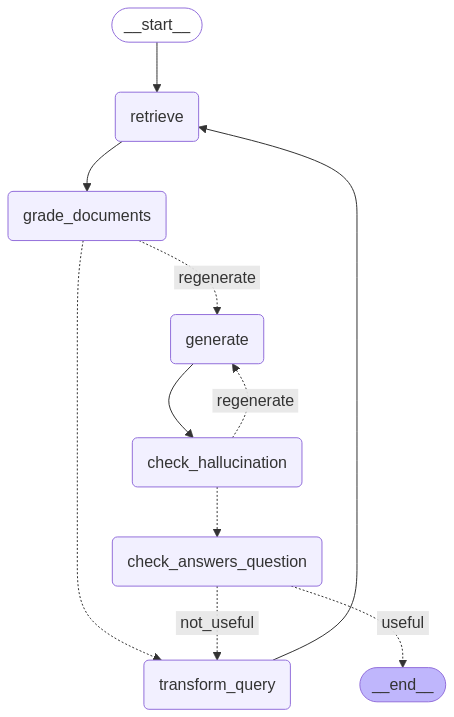

In [98]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


self_rag_graph_builder = StateGraph(GraphState)

# Define the nodes
self_rag_graph_builder.add_node("retrieve", retrieve)  # retrieve
self_rag_graph_builder.add_node("grade_documents", grade_documents)  # grade documents
self_rag_graph_builder.add_node("generate", generate)  # generatae
self_rag_graph_builder.add_node("transform_query", transform_query)  # transform_query
self_rag_graph_builder.add_node(
    "check_hallucination", check_hallucination
)  # check hallucination
self_rag_graph_builder.add_node(
    "check_answers_question", check_answers_question
)  # check answers question

# Build graph
self_rag_graph_builder.add_edge(START, "retrieve")
self_rag_graph_builder.add_edge("retrieve", "grade_documents")
self_rag_graph_builder.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "regenerate": "generate",
    },
)
self_rag_graph_builder.add_edge("generate", "check_hallucination")
self_rag_graph_builder.add_edge("transform_query", "retrieve")
self_rag_graph_builder.add_conditional_edges(
    "check_hallucination",
    hallucination_router,
    {
        "check_answers_question": "check_answers_question",
        "regenerate": "generate",
    },
)
self_rag_graph_builder.add_conditional_edges(
    "check_answers_question",
    answer_quality_router,
    {
        "useful": END,
        "not_useful": "transform_query",
    },
)

# Compile
self_rag_graph = self_rag_graph_builder.compile()

# Visualize the graph
viz_graph(self_rag_graph)

In [95]:
# Run

question = QUESTION_TEMPLATE.format(
    field="total_mineral_resource_tonnage",
    dtype="float",
    default=0,
    description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
)
inputs = {
    "question": question,
    "hallucination_grade": "N/A",
    "hallucination_grader_reasoning": "N/A",
    "answer_grade": "N/A",
    "answer_grader_reasoning": "N/A",
}

value = self_rag_graph.invoke(inputs)

# Final generation
logger.info("---FINAL GENERATION---")
logger.info(value["generation"])

2025-03-16 20:42:24.550 | INFO     | __main__:retrieve:13 - ---RETRIEVE---
2025-03-16 20:42:24.886 | INFO     | __main__:grade_documents:59 - ---CHECK DOCUMENT RELEVANCE TO QUESTION---
2025-03-16 20:42:26.200 | INFO     | __main__:grade_documents:71 - ---GRADE: DOCUMENT RELEVANT---
2025-03-16 20:42:28.495 | INFO     | __main__:grade_documents:71 - ---GRADE: DOCUMENT RELEVANT---
2025-03-16 20:42:29.693 | INFO     | __main__:grade_documents:71 - ---GRADE: DOCUMENT RELEVANT---
2025-03-16 20:42:32.110 | INFO     | __main__:grade_documents:71 - ---GRADE: DOCUMENT RELEVANT---
2025-03-16 20:42:32.111 | INFO     | __main__:decide_to_generate:159 - ---ASSESS GRADED DOCUMENTS---
2025-03-16 20:42:32.111 | INFO     | __main__:decide_to_generate:172 - ---DECISION: GENERATE---
2025-03-16 20:42:32.112 | INFO     | __main__:generate:31 - ---GENERATE---
2025-03-16 20:42:33.530 | INFO     | __main__:check_hallucination:108 - ---CHECK HALLUCINATIONS---
2025-03-16 20:42:35.410 | INFO     | __main__:halluc